Loaded and validated config from configs/M4D/TOS_TL.yaml: {'task': 'segmentation', 'model_name': 'TransOilSeg', 'weights': None, 'transfer_weights': None, 'load_mode': 'best', 'learning_rate': 0.001, 'batch_size': 16, 'num_workers': 4, 'patience': 50, 'delta': 0.005, 'loss': 'dice,ce', 'loss_weights': [0.5, 0.5], 'num_epochs': 500, 'model_save_dir': './results/M4D/TOS/TL', 'metrics': ['mIoU', 'precision', 'recall', 'f1_score'], 'export': False, 'conf_threshold': None, 'save_interval': 5, 'img_size': 224, 'num_classes': 5, 'in_channels': 3, 'datasets': [{'name': 'M4D_dataset', 'train_paths': ['datasets/M4D/train'], 'test_paths': ['datasets/M4D/test']}]}
Loaded custom model 'TransOilSeg' from 'models/TransOilSeg.py'.
Model successfully loaded from ./results/M4D/TOS/TL/TransOilSeg_best.pth, epoch: 68, best_val: 0.4747.
Model compiled with metrics: ['mIoU', 'precision', 'recall', 'f1_score']
Processing images in folder: datasets/M4D/test/images
Processing image: datasets/M4D/test/images/im

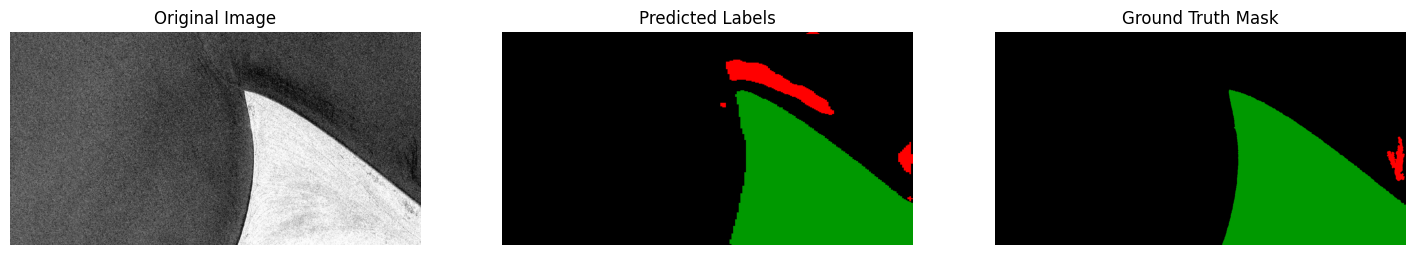

Overall mIoU: 0.4101 | Background: 0.9282 | Oil Spill: 0.5000 | Look-alike: 0.5354 | Ship: 0.5000 | Land: 0.9930 | 
Processing image: datasets/M4D/test/images/img_0099.jpg, mask: datasets/M4D/test/masks/img_0099.png


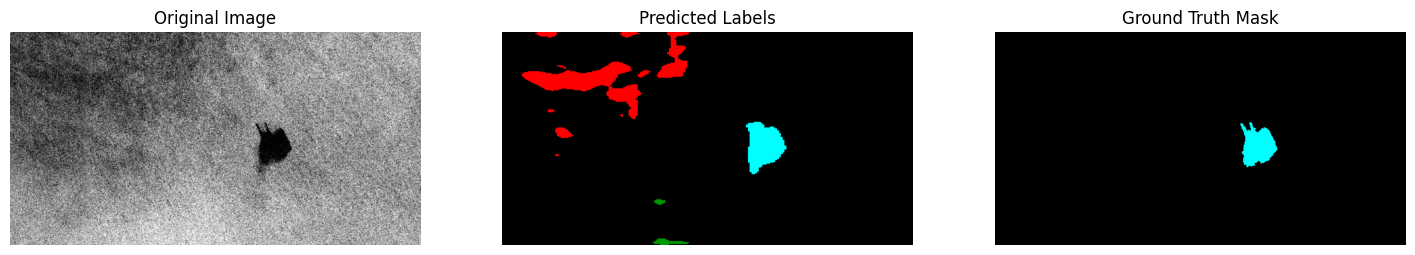

Overall mIoU: 0.3463 | Background: 0.5851 | Oil Spill: 0.8863 | Look-alike: 0.4807 | Ship: 0.5000 | Land: 0.4990 | 
Processing image: datasets/M4D/test/images/img_0037.jpg, mask: datasets/M4D/test/masks/img_0037.png


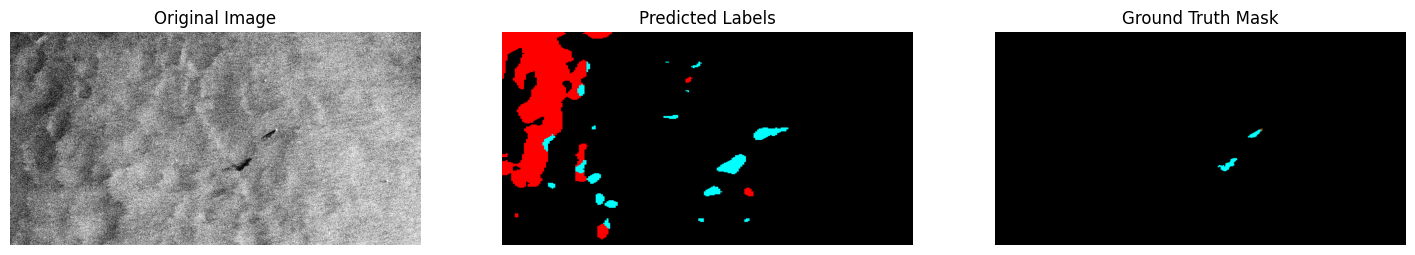

Overall mIoU: 0.2017 | Background: 0.4605 | Oil Spill: 0.5456 | Look-alike: 0.4588 | Ship: 0.5000 | Land: 0.5000 | 


In [ ]:
import torch
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
import matplotlib.pyplot as plt
import random
import dancher_tools as dt
import torchvision.transforms as T
import numpy as np
from PIL import Image

# 定义颜色映射，与类别一致
color_to_class = {
    (0, 0, 0): 0,         # 黑色 - 背景
    (0, 255, 255): 1,     # 青色 - 溢油
    (255, 0, 0): 2,       # 红色 - 似油膜
    (153, 76, 0): 3,      # 棕色 - 船舶
    (0, 153, 0): 4        # 绿色 - 陆地
}

class_to_color = {v: k for k, v in color_to_class.items()}  # 反向映射类别到颜色

class_names = { 
    0: "Background",
    1: "Oil Spill",
    2: "Look-alike",
    3: "Ship",
    4: "Land"
}

def map_mask_to_classes(mask):
    mapped_mask = np.zeros((mask.shape[0], mask.shape[1]), dtype=np.uint8)
    for color, class_idx in color_to_class.items():
        mask_match = (mask == color).all(axis=-1)
        mapped_mask[mask_match] = class_idx
    return mapped_mask

def map_classes_to_rgb(mask):
    rgb_mask = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    for class_idx, color in class_to_color.items():
        rgb_mask[mask == class_idx] = color
    return rgb_mask

def process_test_path(model, image_files, mask_files, device, transform, num_classes=5):
    # 遍历指定的图像和掩码
    for img, msk in zip(image_files, mask_files):
        print(f"Processing image: {img}, mask: {msk}")
        evaluate_model(model, img, msk, device, transform, num_classes)

def evaluate_model(model, image_path, mask_path, device, transform, num_classes):
    image = Image.open(image_path).convert('RGB')
    original_image = np.array(image)
    original_size = image.size  # (width, height)

    # 将图像调整为模型输入大小
    image_tensor = transform(image).unsqueeze(0).to(device)

    if mask_path:
        mask = Image.open(mask_path).convert('RGB')
        mask = np.array(mask)
        mapped_mask = map_mask_to_classes(mask).astype(np.uint8)  # 转换为 np.uint8 类型
        
        # 将掩码大小调整为模型的输出大小
        resized_mask = Image.fromarray(mapped_mask).resize((224, 224), resample=Image.NEAREST)
        mask_tensor = torch.tensor(np.array(resized_mask), dtype=torch.long).unsqueeze(0).to(device)
    else:
        mask_tensor = None

    model.eval()
    with torch.no_grad():
        predicted_labels, _, metrics, per_class_metrics = model.predict(image_tensor, masks=mask_tensor)
    predicted_labels = predicted_labels.squeeze(0).cpu().numpy()

    # 恢复预测结果到原始图像尺寸，并映射回 RGB
    predicted_labels_resized = Image.fromarray(predicted_labels.astype(np.uint8)).resize(
        original_size, resample=Image.NEAREST
    )
    predicted_labels_resized = map_classes_to_rgb(np.array(predicted_labels_resized))

    if mask_path:
        rgb_mapped_mask = map_classes_to_rgb(mapped_mask)

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        axes[0].imshow(original_image)
        axes[0].set_title("Original Image")
        axes[0].axis("off")

        axes[1].imshow(predicted_labels_resized)
        axes[1].set_title("Predicted Labels")
        axes[1].axis("off")

        axes[2].imshow(rgb_mapped_mask)
        axes[2].set_title("Ground Truth Mask")
        axes[2].axis("off")

    else:
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        axes[0].imshow(original_image)
        axes[0].set_title("Original Image")
        axes[0].axis("off")

        axes[1].imshow(predicted_labels_resized)
        axes[1].set_title("Predicted Labels")
        axes[1].axis("off")

    plt.show()

    # 打印mIoU指标
    if metrics and 'mIoU' in metrics:
        print(f"Overall mIoU: {metrics['mIoU']:.4f}", end=" | ")

    # 打印每类别的mIoU
    if per_class_metrics and 'mIoU' in per_class_metrics:
        for cls, mIoU in per_class_metrics['mIoU'].items():
            class_name = class_names.get(cls, f"Unknown ({cls})")
            print(f"{class_name}: {mIoU:.4f}", end=" | ")
        print()  # 换行

def main():
    args = dt.utils.get_config('configs/M4D/TOS_TL.yaml')

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = dt.utils.get_model(args, device)
    model.load(model_dir=args.model_save_dir, mode=args.load_mode, specified_path=args.weights)

    # 定义损失函数和优化器
    metrics = dt.utils.get_metrics(args)
    criterion = dt.utils.get_loss(args)
    optimizer = torch.optim.Adam(model.parameters(), lr=args.learning_rate)
    
    model.compile(criterion=criterion, metrics=metrics)   # Assuming model has a compile method for setup

    transform = T.Compose([
        T.Resize((224, 224)),  # 调整为模型的输入大小
        T.ToTensor(),
        T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
    ])

    # 定义你需要测试的图片和掩码文件
    image_files = [
        'datasets/M4D/test/images/img_0013.jpg',
        'datasets/M4D/test/images/img_0020.jpg',
        'datasets/M4D/test/images/img_0022.jpg',
        'datasets/M4D/test/images/img_0097.jpg'
    ]

    mask_files = [
        'datasets/M4D/test/masks/img_0013.png',
        'datasets/M4D/test/masks/img_0020.png',
        'datasets/M4D/test/masks/img_0022.png',
        'datasets/M4D/test/masks/img_0097.png'
    ]

    process_test_path(model, image_files, mask_files, device, transform)

if __name__ == '__main__':
    main()
